In [1]:
from __future__ import annotations

import argparse
import importlib.util
import logging
import sys
import time
import types
from pathlib import Path

from src.utils import pmf_utils
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import torch

from src.ddm.ddm3 import DecisionModel, FreeParam, FixedParam

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device: {device}")

INFO:__main__:Using device: cuda


In [2]:
COHERENCES     = np.array([-0.50, -0.18, -0.09, 0.0, 0.09, 0.18, 0.50]).round(2)
TRIALS_PER_COH = 150

MAX_DURATION     = 3.0
DT               = 0.001

MOMENT_WEIGHT = 1.0
ESP = 1e-12
ENTROPY_FLOOR = 0.2

In [3]:
fixed_params = {
    "dt": FixedParam(0.001),
    "variance": FixedParam(1.0),
}


free_params = {
    "ndt": FreeParam(0.1, 1),
    "a": FreeParam(0.8, 6.0),
    "z": FreeParam(0.1, 0.9),
    "drift_gain": FreeParam(1.0, 10.0),
    "drift_offset": FreeParam(-5.0, 5.0),
    "leak_rate": FreeParam(0.0, 5.0),
    "time_constant": FreeParam(-5.0, 5.0),
}

class DDMModel(DecisionModel):

    def __init__(self, fixed_params, free_params):
        super().__init__(free_params=free_params, fixed_params=fixed_params, device=device, likelihood_params={
            "moment_weight": MOMENT_WEIGHT,
            "eps": ESP,
            "entropy_floor": ENTROPY_FLOOR
        })

    def _objective_function(self, values, data, stimulus, n_reps, seed, l1_weight):
        try:
            params = self._build_params(values)
        except ValueError:
            return 1e6
        result = self._simulate_condition(stimulus, params, n_reps)
        if result is None:
            return 1e6
        return self.likelihood_calc.calculate_likelihood(
            result["rt"], result["choice"],
            np.asarray(data["rt"]), np.asarray(data["choice"]),
            result["signed_coherence"], np.asarray(data["signed_coherence"]),
        )

    def _objective_function(self, values, data, stimulus, n_reps, l1_weight):
        try:
            params = self._build_params(values)
        except ValueError:
            return 1e6

        sim = self._simulate_condition(
            stimulus,
            params,
            n_reps,
        )

        if sim is None:
            return 1e6

        return self.likelihood_calc.calculate_likelihood(
            sim["rt"].values,
            sim["choice"].values,
            np.asarray(data["rt"]),
            np.asarray(data["choice"]),
            sim["signed_coherence"].values,
            np.asarray(data["signed_coherence"]),
        )


ddm_model = DDMModel(
    fixed_params=fixed_params,
    free_params=free_params,
)

INFO:src.ddm.simulator:DriftDiffusionSimulator using _TorchSimulator backend on cuda
INFO:src.ddm.ddm3:Initialized DDMModel | device=cuda


In [4]:
def plot_mean_data(data):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cohs_sorted = sorted(data["signed_coherence"].unique())

    # Psychometric function
    p_upper = []
    for coh in cohs_sorted:
        subset = data[data["signed_coherence"] == coh].dropna()
        p_upper.append((subset["choice"] == 1).mean())

    axes[0].plot(cohs_sorted, p_upper, "o-", color="steelblue")
    axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    axes[0].axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    axes[0].set_xlabel("Coherence")
    axes[0].set_ylabel("P(upper boundary)")
    axes[0].set_title("Psychometric Function")
    axes[0].set_ylim(0, 1)

    # Chronometric function
    mean_rt  = []
    sem_rt   = []
    for coh in cohs_sorted:
        subset = data[data["signed_coherence"] == coh].dropna()
        mean_rt.append(subset["rt"].mean())
        sem_rt.append(subset["rt"].sem())

    axes[1].errorbar(cohs_sorted, mean_rt, yerr=sem_rt, fmt="o-", color="tomato", capsize=4)
    axes[1].axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    axes[1].set_xlabel("Coherence")
    axes[1].set_ylabel("Mean RT (s)")
    axes[1].set_title("Chronometric Function")

    plt.tight_layout()
    plt.show()

# for each coherence plot histogram of RTs for choice 0 and choice 1
def plot_raw_data(data):

    fig, axes = plt.subplots(len(data["signed_coherence"].unique()), 1, figsize=(8, 3 * len(data["signed_coherence"].unique())))

    for ax, coh in zip(axes, sorted(data["signed_coherence"].unique())):
        subset = data[data["signed_coherence"] == coh]
        ax.hist(subset[subset["choice"] == 0]["rt"], bins=20, alpha=0.5, label="choice 0", color="steelblue")
        ax.hist(subset[subset["choice"] == 1]["rt"], bins=20, alpha=0.5, label="choice 1", color="tomato")
        ax.set_title(f"Coherence: {coh:+.2f}")
        ax.set_xlabel("RT (s)")
        ax.set_ylabel("Count")
        ax.set_xlim(0, data["rt"].max() + 0.5)
        ax.legend()

    plt.tight_layout()
    plt.show()

# Generate Data

In [5]:
def make_stimulus() -> np.ndarray:
    n_tp = int(MAX_DURATION / DT)
    coh  = np.repeat(COHERENCES, TRIALS_PER_COH)
    return np.tile(coh.reshape(-1, 1), (1, n_tp)).astype(np.float32)

def generate_data_simple(params: dict = None, trials=TRIALS_PER_COH, max_duration=MAX_DURATION):
    """Like generate_data() but uses the ddm_simple dict-based API."""
    if params is None:
        params = dict(DEFAULT_PARAMS)

    stimulus   = make_stimulus()
    sim        = DriftDiffusionSimulator(device="cuda")
    rt, choice = sim.simulate_trials(stimulus, params)

    coherences = stimulus[:, 0]

    return pd.DataFrame({"signed_coherence": coherences, "rt": rt, "choice": choice}), stimulus

Data likelihood under original parameters: 0.0
   signed_coherence  n_trials  n_choice_0  n_choice_1  n_nan
0             -0.50       150         148           2      0
1             -0.18       150         124          26      0
2             -0.09       150         103          47      0
3              0.00       150          58          92      0
4              0.09       150          46         104      0
5              0.18       150          34         116      0
6              0.50       150           0         150      0


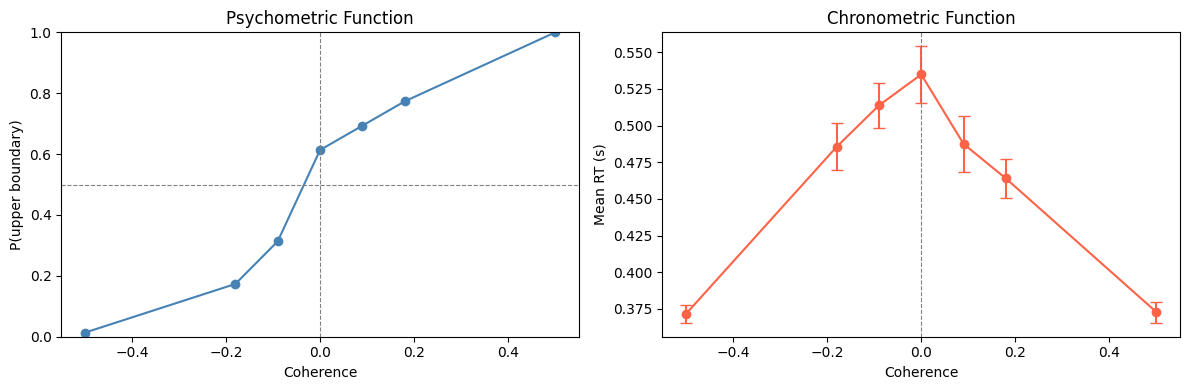

In [6]:
# calculate likelihood for original parameters (before fitting) for comparison
original_params = {
    "ndt": 0.25,
    "a": 1.0,
    "z": 0.5,
    "drift_gain": 8.0,
    "drift_offset": 0.0,
    "variance": 1.0,
    "leak_rate": 0.1,
    "time_constant": 0,#0.5,
    "dt": 0.001,
}

stimulus = make_stimulus()

data = ddm_model.simulate(stimulus, original_params)


# count number of 0, 1 and NaN in each coherence bin
summary = data.groupby("signed_coherence")["choice"].agg(
    n_trials="count",
    n_choice_0=lambda x: np.sum(x == 0),
    n_choice_1=lambda x: np.sum(x == 1),
    n_nan=lambda x: np.sum(np.isnan(x)),
).reset_index()

likelihood = ddm_model.likelihood_calc.calculate_likelihood(
    data["rt"], data["choice"],
    data["rt"], data["choice"],
    data["signed_coherence"], data["signed_coherence"],
)

print(f"Data likelihood under original parameters: {likelihood:.1f}")


print(summary)

plot_mean_data(data)
# plot_raw_data(data)

# Recovery Trial

### DDM Simple

In [7]:
result_cuda = ddm_model.fit(
    data={"rt": data["rt"], "choice": data["choice"], "signed_coherence": data["signed_coherence"]},
    stimulus=stimulus,
    max_iterations=1000,
    n_reps=15,
    l1_weight=0,
)

INFO:src.ddm.ddm3:Starting optimization (DDMModel)...
INFO:src.ddm.ddm3:Iter   1 | NLL=25489.2254 | convergence=0.0202 | ndt=0.5605  a=2.2011  z=0.6136  drift_gain=7.3628  drift_offset=0.8217  leak_rate=1.2283  time_constant=3.0092
INFO:src.ddm.ddm3:Iter   2 | NLL=24695.4709 | convergence=0.0267 | ndt=0.3258  a=1.1249  z=0.2546  drift_gain=6.0811  drift_offset=-0.1358  leak_rate=4.5905  time_constant=2.2122
INFO:src.ddm.ddm3:Iter   3 | NLL=17358.8333 | convergence=0.0296 | ndt=0.2089  a=5.5295  z=0.3058  drift_gain=9.1289  drift_offset=0.2633  leak_rate=1.3541  time_constant=-0.4251
INFO:src.ddm.ddm3:Iter   4 | NLL=17358.8333 | convergence=0.0349 | ndt=0.2089  a=5.5295  z=0.3058  drift_gain=9.1289  drift_offset=0.2633  leak_rate=1.3541  time_constant=-0.4251
INFO:src.ddm.ddm3:Iter   5 | NLL=6387.4318 | convergence=0.0327 | ndt=0.1249  a=4.4540  z=0.5242  drift_gain=5.3311  drift_offset=4.3973  leak_rate=4.0521  time_constant=-0.2775
INFO:src.ddm.ddm3:Iter   6 | NLL=6387.4318 | converge

# plot model simulations

In [ ]:
def plot_ddm_fit(data, sim, coherences=None, title="DDM Fit"):
    """
    Overlay observed data (dots) and model predictions (lines).

    data : DataFrame or dict with keys 'rt', 'choice', 'coherence'
    sim  : DataFrame or dict with keys 'rt', 'choice', 'coherence'
    """
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data)
    if not isinstance(sim, pd.DataFrame):
        sim = pd.DataFrame(sim)

    cohs = sorted(coherences if coherences is not None else data["signed_coherence"].unique())

    def summarize(df):
        p_upper, mean_rt_upper, mean_rt_lower = [], [], []
        for c in cohs:
            subset = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
            p_upper.append((subset["choice"] == 1).mean() if len(subset) > 0 else np.nan)
            upper = subset[subset["choice"] == 1]["rt"]
            lower = subset[subset["choice"] == 0]["rt"]
            mean_rt_upper.append(upper.mean() if len(upper) > 0 else np.nan)
            mean_rt_lower.append(lower.mean() if len(lower) > 0 else np.nan)
        return np.array(p_upper), np.array(mean_rt_upper), np.array(mean_rt_lower)

    d_p, d_rt1, d_rt0 = summarize(data)
    s_p, s_rt1, s_rt0 = summarize(sim)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(title)

    # --- Psychometric ---
    ax1.plot(cohs, s_p, color="steelblue", label="model")
    ax1.scatter(cohs, d_p, color="steelblue", zorder=5, label="data")
    ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax1.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set(xlabel="Coherence", ylabel="P(upper boundary)", title="Psychometric", ylim=(0, 1))
    ax1.legend()

    # --- Chronometric ---
    ax2.plot(cohs, s_rt1, color="steelblue", label="model upper")
    ax2.plot(cohs, s_rt0, color="tomato",    label="model lower")
    ax2.scatter(cohs, d_rt1, color="steelblue", zorder=5, label="data upper")
    ax2.scatter(cohs, d_rt0, color="tomato",    zorder=5, label="data lower")
    ax2.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax2.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric")
    ax2.legend()

    plt.tight_layout()
    return fig

In [ ]:
def model_comparison():
    fitted_params = result_cuda["parameters"]
    sim = ddm_model.simulate(stimulus, params=fitted_params, n_reps=10, seed=0)
    return sim

## Likelihood Calculator

In [ ]:
fitted_llh, origin_param_llh = [], []

sim_data_original = pd.DataFrame(ddm_model.simulate(
    stimulus, params=original_params, n_reps=10, seed=0
))

for i in range(100):
    sim_data_cuda = model_comparison()

    llh_cuda = ddm_model.likelihood_calc.calculate_likelihood(
        sim_data_cuda["rt"].values, sim_data_cuda["choice"].values,
        data["rt"].values, data["choice"].values,
        sim_data_cuda["signed_coherence"].values, data["signed_coherence"].values,
    )
    llh_original_param = ddm_model.likelihood_calc.calculate_likelihood(
        sim_data_original["rt"].values, sim_data_original["choice"].values,
        data["rt"].values, data["choice"].values,
        sim_data_original["signed_coherence"].values, data["signed_coherence"].values,
    )

    fitted_llh.append(llh_cuda)
    origin_param_llh.append(llh_original_param)

llh_data = ddm_model.likelihood_calc.calculate_likelihood(
    data["rt"].values, data["choice"].values,
    data["rt"].values, data["choice"].values,
    data["signed_coherence"].values, data["signed_coherence"].values,
)

print(f"Data vs itself:   {llh_data:.1f}  (should be 0)")
print(f"Original params:  {np.mean(origin_param_llh):.1f} ± {np.std(origin_param_llh):.1f}")
print(f"Fitted params:    {np.mean(fitted_llh):.1f} ± {np.std(fitted_llh):.1f}  (should be ≤ original)")

In [ ]:
def plot_ddm_fit(data, sim, coherences=None, title="DDM Fit"):
    """
    Overlay observed data (dots) and model predictions (lines).

    data : DataFrame or dict with keys 'rt', 'choice', 'coherence'
    sim  : DataFrame or dict with keys 'rt', 'choice', 'coherence'
    """
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data)
    if not isinstance(sim, pd.DataFrame):
        sim = pd.DataFrame(sim)

    data = data.copy()
    sim  = sim.copy()
    data["signed_coherence"] = data["signed_coherence"].round(2)
    sim["signed_coherence"]  = sim["signed_coherence"].round(2)

    cohs = sorted(coherences if coherences is not None else data["signed_coherence"].unique())

    def summarize(df):
        p_upper, mean_rt_upper, mean_rt_lower = [], [], []
        for c in cohs:
            subset = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
            p_upper.append((subset["choice"] == 1).mean() if len(subset) > 0 else np.nan)
            upper = subset[subset["choice"] == 1]["rt"]
            lower = subset[subset["choice"] == 0]["rt"]
            mean_rt_upper.append(upper.mean() if len(upper) > 0 else np.nan)
            mean_rt_lower.append(lower.mean() if len(lower) > 0 else np.nan)
        return np.array(p_upper), np.array(mean_rt_upper), np.array(mean_rt_lower)

    d_p, d_rt1, d_rt0 = summarize(data)
    s_p, s_rt1, s_rt0 = summarize(sim)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(title)

    # --- Psychometric ---
    ax1.plot(cohs, s_p, color="steelblue", label="model")
    ax1.scatter(cohs, d_p, color="steelblue", zorder=5, label="data")
    ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax1.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set(xlabel="Coherence", ylabel="P(upper boundary)", title="Psychometric", ylim=(0, 1))
    ax1.legend()

    # --- Chronometric ---
    ax2.plot(cohs, s_rt1, color="steelblue", label="model upper")
    ax2.plot(cohs, s_rt0, color="tomato",    label="model lower")
    ax2.scatter(cohs, d_rt1, color="steelblue", zorder=5, label="data upper")
    ax2.scatter(cohs, d_rt0, color="tomato",    zorder=5, label="data lower")
    ax2.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax2.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric")
    ax2.legend()

    plt.tight_layout()
    # return fig

In [ ]:
plot_ddm_fit(sim_data_cuda, data, title="CUDA Fit vs Data")

# Trajectory Checking

In [ ]:
# calculate likelihood for original parameters (before fitting) for comparison
original_params = {
    "ndt": 0.25,
    "a": 1.0,
    "z": 0.5,
    "drift_gain": 8.0,
    "drift_offset": 0.0,
    "variance": 1.0,
    "leak_rate": 0.1,
    "time_constant": 0,#0.5,
    "dt": 0.001,

}

stimulus = make_stimulus()

simple_model = SimpleModel()


data = pd.DataFrame(simple_model.simulate(
    stimulus, params=original_params, n_reps=10, seed=0
))

# count number of 0, 1 and NaN in each coherence bin
summary = data.groupby("signed_coherence")["choice"].agg(
    n_trials="count",
    n_choice_0=lambda x: np.sum(x == 0),
    n_choice_1=lambda x: np.sum(x == 1),
    n_nan=lambda x: np.sum(np.isnan(x)),
).reset_index()


# data likelihood under original parameters
likelihood = simple_model.likelihood_calc.calculate_likelihood(
    data["rt"], data["choice"],
    data["rt"], data["choice"],
    data["signed_coherence"], data["signed_coherence"],
)

print(f"Data likelihood under original parameters: {likelihood:.1f}")


# print(summary)

# plot_mean_data(data)
# plot_raw_data(data)

In [ ]:
class DriftDiffusionSimulatorCUDA:
    """
    PyTorch GPU/CPU simulator.

    No-leak path: fully vectorized — cumsum builds the entire evidence
    trajectory in one shot, argmax finds the first boundary crossing.
    No Python loop over timesteps.

    Leak path: falls back to the sequential loop (leak couples timesteps,
    breaking the cumsum decomposition).
    """

    def __init__(self, device: str | None = None):
        if device == "cuda" and not torch.cuda.is_available():
            logger.warning("CUDA requested but unavailable, falling back to CPU.")
            device = "cpu"
        self.device = torch.device(
            device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        )
        logger.info("Using device: %s", self.device)

    def simulate_trials(
        self, stimulus: np.ndarray | torch.Tensor, params: dict
    ) -> tuple[np.ndarray, np.ndarray]:
        dev = self.device
        if isinstance(stimulus, torch.Tensor):
            stim = stimulus.to(dev, dtype=torch.float32)
        else:
            # Cache the GPU tensor: during fitting the same numpy array is passed
            # thousands of times. Re-uploading it on every call is the main GPU
            # bottleneck. We key the cache on the array's data pointer + shape.
            ptr = stimulus.__array_interface__["data"][0]
            key = (ptr, stimulus.shape)
            if getattr(self, "_stim_cache_key", None) != key:
                self._stim_cache_key = key
                self._stim_cache     = torch.tensor(stimulus, device=dev, dtype=torch.float32)
            stim = self._stim_cache
        n_trials, n_timepoints = stim.shape
        T = n_timepoints - 1

        a             = float(params["a"])
        z             = float(params["z"])
        ndt           = float(params["ndt"])
        drift_gain    = float(params["drift_gain"])
        drift_offset  = float(params["drift_offset"])
        variance      = float(params["variance"])
        dt            = float(params["dt"])
        leak_rate     = float(params["leak_rate"])
        time_constant = float(params["time_constant"])

        sp        = z * a
        noise_std = (variance * dt) ** 0.5

        # valid[i]: step t=i+1 is live (stim not NaN)
        valid     = ~torch.isnan(stim[:, 1:])                                 # (N, T)
        drift_inc = torch.nan_to_num((drift_gain * stim[:, :-1] + drift_offset) * dt)  # (N, T)
        noise_inc = torch.randn(n_trials, T, device=dev) * noise_std          # (N, T)

        if leak_rate == 0.0:
            # ------------------------------------------------------------------
            # No-leak: evidence is a simple cumsum of increments
            # ------------------------------------------------------------------
            evidence = sp + torch.cumsum((drift_inc + noise_inc) * valid, dim=1)
        else:
            # ------------------------------------------------------------------
            # Leak: e[t] = α·e[t-1] + b[t],  α = 1 − leak·dt
            #
            # Closed-form solution via FFT convolution (no Python time loop):
            #   e[t] = αᵗ·sp  +  Σ_{j=0}^{t-1} α^{t-1-j} · b[j]
            #        = αᵗ·sp  +  (b ★ w)[t-1]   where w[k] = αᵏ
            #
            # Crossing detection uses valid mask so the decaying evidence
            # after a NaN stimulus never triggers a false crossing.
            # ------------------------------------------------------------------
            α   = 1.0 - leak_rate # * dt
            # forcing term includes the leak's pull toward sp
            # b   = (drift_inc + noise_inc + sp * leak_rate * dt) * valid       # (N, T)
            b   = (drift_inc + noise_inc + sp * leak_rate * 1) * valid       # (N, T)

            fft_n = 1 << (2 * T - 1).bit_length()   # next power-of-2 ≥ 2T-1
            k     = torch.arange(T, device=dev, dtype=torch.float32)
            w     = torch.tensor(α, device=dev, dtype=torch.float32).pow(k)   # (T,)

            particular = torch.fft.irfft(
                torch.fft.rfft(b, n=fft_n, dim=1) * torch.fft.rfft(w, n=fft_n),
                n=fft_n, dim=1,
            )[:, :T]                                                           # (N, T)

            t_exp    = torch.arange(1, T + 1, device=dev, dtype=torch.float32)
            evidence = torch.tensor(α, device=dev).pow(t_exp) * sp + particular  # (N, T)

        if time_constant != 0.0:
            t_idx        = torch.arange(1, n_timepoints, device=dev, dtype=torch.float32)
            decision_var = sp + (evidence - sp) * (1.0 + t_idx * dt * time_constant)
        else:
            decision_var = evidence

        upper   = (decision_var >= a) & valid
        lower   = (decision_var <= 0) & valid
        crossed = upper | lower

        rt     = torch.full((n_trials,), float("nan"), device=dev, dtype=torch.float32)
        choice = torch.full((n_trials,), float("nan"), device=dev, dtype=torch.float32)

        has_crossed = crossed.any(dim=1)
        if has_crossed.any():
            first_idx       = crossed[has_crossed].int().argmax(dim=1)
            rt[has_crossed] = (first_idx.float() + 1) * dt + ndt
            choice[has_crossed] = (
                upper[has_crossed]
                .gather(1, first_idx.unsqueeze(1))
                .squeeze(1)
                .float()
            )

        return rt.cpu().numpy(), choice.cpu().numpy()

In [ ]:
def simulate_with_trajectories(params, coherences, n_per_coh=5, max_duration=MAX_DURATION, seed=0):
    """Re-run DDM simulation and return full evidence trajectories alongside rt/choice."""
    torch.manual_seed(seed)

    dt            = float(params.get("dt", DT))
    a             = float(params["a"])
    z             = float(params["z"])
    ndt           = float(params["ndt"])
    drift_gain    = float(params["drift_gain"])
    drift_offset  = float(params.get("drift_offset", 0.0))
    variance      = float(params.get("variance", 1.0))
    leak_rate     = float(params.get("leak_rate", 0.0))
    time_constant = float(params.get("time_constant", 0.0))

    n_tp     = int(max_duration / dt)
    coh_arr  = np.repeat(np.array(coherences, dtype=np.float32), n_per_coh)
    stim_t   = torch.tensor(
        np.tile(coh_arr.reshape(-1, 1), (1, n_tp)), dtype=torch.float32
    )
    N, n_timepoints = stim_t.shape
    T = n_timepoints - 1

    sp        = z * a
    noise_std = (variance * dt) ** 0.5

    valid     = ~torch.isnan(stim_t[:, 1:])
    drift_inc = torch.nan_to_num((drift_gain * stim_t[:, :-1] + drift_offset) * dt)
    noise_inc = torch.randn(N, T) * noise_std

    if leak_rate == 0.0:
        evidence = sp + torch.cumsum((drift_inc + noise_inc) * valid, dim=1)
    else:
        alpha = 1.0 - leak_rate * dt
        b     = (drift_inc + noise_inc + sp * leak_rate * dt) * valid
        fft_n = 1 << (2 * T - 1).bit_length()
        k     = torch.arange(T, dtype=torch.float32)
        w     = torch.tensor(alpha).pow(k)
        particular = torch.fft.irfft(
            torch.fft.rfft(b, n=fft_n, dim=1) * torch.fft.rfft(w, n=fft_n),
            n=fft_n, dim=1,
        )[:, :T]
        t_exp    = torch.arange(1, T + 1, dtype=torch.float32)
        evidence = torch.tensor(alpha).pow(t_exp) * sp + particular

    if time_constant != 0.0:
        t_idx        = torch.arange(1, n_timepoints, dtype=torch.float32)
        decision_var = sp + (evidence - sp) * (1.0 + t_idx * dt * time_constant)
    else:
        decision_var = evidence

    upper   = (decision_var >= a) & valid
    lower   = (decision_var <= 0) & valid
    crossed = upper | lower

    rt     = np.full(N, np.nan)
    choice = np.full(N, np.nan)
    has_crossed = crossed.any(dim=1).numpy()
    if has_crossed.any():
        first_idx = crossed[has_crossed].int().argmax(dim=1).numpy()
        rt[has_crossed]     = (first_idx + 1) * dt + ndt
        choice[has_crossed] = (
            upper[has_crossed]
            .gather(1, torch.tensor(first_idx[:, None]))
            .squeeze(1).float().numpy()
        )

    # prepend starting point so trajectories[i, 0] == sp
    trajectories = torch.cat(
        [torch.full((N, 1), sp), decision_var], dim=1
    ).numpy()

    return dict(
        trajectories=trajectories,
        coherences=coh_arr,
        rt=rt,
        choice=choice,
        t=np.arange(n_timepoints) * dt,
        a=a,
        sp=sp,
        dt=dt,
        ndt=ndt,
    )


def plot_trajectories(params, coherences=COHERENCES, n_per_coh=8, seed=42, max_t=1.5):
    res   = simulate_with_trajectories(params, coherences, n_per_coh=n_per_coh, seed=seed)
    traj  = res["trajectories"]       # (N, n_tp)
    t     = res["t"]
    cohs  = res["coherences"]
    rt    = res["rt"]
    choice = res["choice"]
    a     = res["a"]
    sp    = res["sp"]
    dt    = res["dt"]

    t_mask = t <= max_t
    t_plot = t[t_mask]

    n_cohs = len(coherences)
    ncols  = min(4, n_cohs)
    nrows  = int(np.ceil(n_cohs / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.5 * nrows), sharey=True)
    axes = np.array(axes).reshape(nrows, ncols)

    for idx, coh in enumerate(sorted(coherences)):
        ax   = axes[idx // ncols, idx % ncols]
        mask = np.round(cohs, 2) == round(coh, 2)

        for traj_i, rt_i, ch_i in zip(traj[mask], rt[mask], choice[mask]):
            if np.isfinite(rt_i):
                cross_step = min(int((rt_i - res["ndt"]) / dt) + 2, len(t))
                x = t[:cross_step][t[:cross_step] <= max_t]
                y = traj_i[:len(x)]
            else:
                x, y = t_plot, traj_i[t_mask]

            color = "steelblue" if ch_i == 1.0 else ("tomato" if ch_i == 0.0 else "gray")
            ax.plot(x, y, color=color, alpha=0.55, linewidth=0.9)

        ax.axhline(a,  color="k",    linestyle="--", linewidth=1.0)
        ax.axhline(0,  color="k",    linestyle="--", linewidth=1.0)
        ax.axhline(sp, color="gray", linestyle=":",  linewidth=0.8)
        ax.set_title(f"coh = {coh:+.2f}")
        ax.set_xlabel("Time (s)")
        # ax.set_xlim(0, max_t)
        ax.set_ylim(-0.15, a + 0.15)
        if idx % ncols == 0:
            ax.set_ylabel("Evidence")

    print(f"Mean RTs by coherence:")
    for coh in sorted(coherences):
        mask = np.round(cohs, 2) == round(coh, 2)
        mean_rt = np.nanmean(rt[mask])
        print(f"  coh = {coh:+.2f}: {mean_rt:.3f} s")

    # hide any unused axes
    for idx in range(n_cohs, nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)

    # legend
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], color="steelblue", label="upper boundary hit"),
        Line2D([0], [0], color="tomato",    label="lower boundary hit"),
        Line2D([0], [0], color="gray",      label="no decision"),
        Line2D([0], [0], color="k", linestyle="--", label="boundaries"),
        Line2D([0], [0], color="gray", linestyle=":", label="start point"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=5,
               bbox_to_anchor=(0.5, -0.02), frameon=False)
    fig.suptitle("Evidence Accumulation Trajectories", y=1.01)
    plt.tight_layout()
    plt.show()


In [ ]:

param_1 = {
    "ndt": 0.25,
    "a": 1.0,
    "z": 0.5,
    "drift_gain": 8.0,
    "drift_offset": 0.0,
    "variance": 1.0,
    "leak_rate": 0.1,
    "time_constant": 0,#0.5,
    "dt": 0.001,
}


param_2 = {
    "ndt": 0.25,
    "a": 1.0,
    "z": 0.5,
    "drift_gain": 8.0,
    "drift_offset": 0.0,
    "variance": 1.0,
    "leak_rate": 5,
    "time_constant": 0,#0.5,
    "dt": 0.001,
}
plot_trajectories(param_1, coherences=[0.5], n_per_coh=100)
plot_trajectories(param_2, coherences=[0.5], n_per_coh=100)

# Prepare Data

In [ ]:
# behavior_df.to_csv(Path(processed_dir, "ddm", "behavior_data.csv"), index=False)